# <img src="assets/logo_infnetv1.png" alt="Infnet logo" height="45"/> Projeto de Disciplina - Processamento de linguagem natural


### Aluno: 

- Lauro Barbosa <a href="https://github.com/LMRocha/NLP_BBC-News-Classification"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/></a>


### Descrição do projeto:
O dataset utiliza de 2225 artigos da BBC categorizadas  business, entertainment, politics, sport or tech

## Importação as bibliotecas

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import re
from dotenv import load_dotenv
import os
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi
import seaborn as sns
import warnings
import nltk
import spacy
import csv
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from wordcloud import WordCloud
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from nltk.tokenize import word_tokenize
import networkx as nx
import time
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
stop_words = set(stopwords.words('english'))

warnings.filterwarnings('ignore')
load_dotenv()
SEED=42

## Geração dos diretórios e download do dataset

In [67]:
# Inicializar a API do Kaggle
api = KaggleApi()
api.authenticate()

# Criar o diretório se não existir
data_path = 'data'
os.makedirs(data_path, exist_ok=True)

# Baixar os dados do Kaggle
api.dataset_download_files('hgultekin/bbcnewsarchive', path=data_path, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive


## Declaração de funções

### Funções de preparação de texto

In [68]:
def tokenize(text):
    return text.split()

def normalize(text):   
    return text.lower()

def clean_text(text):
    return re.sub(r'[^a-z\s]', '', text)

def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(t) for t in tokens]

def stemmize(tokens):
    stemmizer = PorterStemmer();
    return [stemmizer.stem(t) for t in tokens]

def apply_pos_tagging(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    filtered_words = [
        token.lemma_
        for token in doc
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']
            and not token.is_stop
    ]

    return " ".join(filtered_words)

def preprocess_text(text, is_lemmatize: bool, is_stemmize: bool, is_pos_tagging: bool):
    text = normalize(text)
    text = clean_text(text)
    stop_words = set(stopwords.words('english'))
    tokens = tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    
    if is_lemmatize:
        tokens = lemmatize(tokens)
        return ' '.join(tokens)
    elif is_stemmize:
        tokens = stemmize(tokens)
        return ' '.join(tokens)
    elif is_pos_tagging:
        apply_pos_tagging(text)

def plot_word_cloud(processed_text):
    text = " ".join(processed_text)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

def plot_bar_frequencia(processed_text):
    all_words = " ".join(processed_text).split()
    word_freq = Counter(all_words)
    common_words = word_freq.most_common(10)
    words = [word[0] for word in common_words]
    counts = [word[1] for word in common_words]

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title("Top 10 Words")
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.show()

### Funções de vetorização

In [69]:
def vetorizer_tfidf(docs):
    return TfidfVectorizer().fit_transform(docs)

def vetorizer_bow(docs):
    return CountVectorizer().fit_transform(docs)

def vetorizer_bow_ngrams(docs,bow_ngram_model):
    return bow_ngram_model.fit_transform(docs)

def vetorizer_word2vec(sentences, vector_size=5, window=2, min_count=1):
    model = Word2Vec(sentences, vector_size=vector_size, window=window, min_count=min_count, workers=4)
    doc_vectors = []
    for doc in sentences:
        word_vectors = [model.wv[word] for word in doc if word in model.wv]
        if word_vectors:
            doc_vector = np.mean(word_vectors, axis=0)
        else:
            doc_vector = np.zeros(vector_size)
        doc_vectors.append(doc_vector)
    return np.array(doc_vectors)



### Funções de busca

In [70]:
def buscar(query, vectorizer, X_matrix, y_labels, original_texts, top_k=5):
    query_proc = preprocess_text(query, is_lemmatize=True, is_stemmize=False, is_pos_tagging=False)
    q_vec = vectorizer.transform([query_proc])
    scores = cosine_similarity(q_vec, X_matrix).flatten()
    indices = scores.argsort()[::-1][:top_k]
    print(f"Query: '{query}'\n")
    for i, idx in enumerate(indices, 1):
        print(f"{i}. Similaridade: {scores[idx]:.4f} | Categoria: {y_labels[idx]}")
        print(f"   Excerto: {original_texts[idx][:150]}...\n")
    return query_proc,q_vec,scores,indices

def buscar_w2v(query, w2v_model, doc_vectors, y_labels, original_texts, top_k=5):
    query_proc = preprocess_text(query, is_lemmatize=True, is_stemmize=False, is_pos_tagging=False)
    tokens = query_proc.split()
    word_vecs = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if word_vecs:
        q_vec = np.mean(word_vecs, axis=0)
    else:
        q_vec = np.zeros(w2v_model.wv.vector_size)
    scores = cosine_similarity([q_vec], doc_vectors).flatten()
    indices = scores.argsort()[::-1][:top_k]
    print(f"Query: '{query}'\n")
    for i, idx in enumerate(indices, 1):
        print(f"{i}. Similaridade: {scores[idx]:.4f} | Categoria: {y_labels[idx]}")
        print(f"   Excerto: {original_texts[idx][:150]}...\n")
    return query_proc,q_vec,scores,indices


def plot_category_distribution(y_labels, indices, top_k=5):
    categories = [y_labels[i] for i in indices[:top_k]]
    cat_counts = Counter(categories)
    plt.figure(figsize=(8, 6))
    plt.pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("pastel"))
    plt.title(f"Distribuição de Categorias nos Top-{top_k} Resultados")
    plt.show()

def plot_pca_projection(doc_vectors, indices, query_vec=None, top_k=5):
    if query_vec is not None:
        all_vecs = np.vstack([doc_vectors, query_vec.reshape(1, -1)])
        labels = ['Doc'] * len(doc_vectors) + ['Query']
    else:
        all_vecs = doc_vectors
        labels = ['Doc'] * len(doc_vectors)
    
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(all_vecs)
    
    doc_coords = coords[:len(doc_vectors)]
    if query_vec is not None:
        query_coord = coords[-1]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(doc_coords[:, 0], doc_coords[:, 1], c='lightgray', alpha=0.6, label='Documentos')
    
    top_coords = doc_coords[indices[:top_k]]
    plt.scatter(top_coords[:, 0], top_coords[:, 1], c='red', s=100, label='Top K Resultados')
    
    for i, idx in enumerate(indices[:top_k]):
        plt.annotate(f"#{i+1}", (top_coords[i, 0], top_coords[i, 1]), fontsize=9)
    
    if query_vec is not None:
        plt.scatter(query_coord[0], query_coord[1], c='blue', s=200, marker='*', label='Query')
    
    plt.title("Projeção PCA dos Vetores dos Documentos")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Funções de análise

In [71]:
def count_tokens(text):
    return len(text.split())

def get_top_words(category, df_clean, n=10):
    texts = df_clean[df_clean['category'] == category]['processed_text']
    all_words = []
    for text in texts:
        tokens = text.split()
        all_words.extend(tokens)
    counter = Counter(all_words)
    return counter.most_common(n)


def plot_analise_robustes(df_clean):
    df_clean['token_count'] = df_clean['processed_text'].apply(lambda x: len(x.split()))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_clean['token_count'], bins=30, kde=True)
    plt.title('Distribuição do número de palavras por documento')
    plt.xlabel('Número de palavras')
    plt.ylabel('Frequência')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x='category', y='token_count', data=df_clean)
    plt.title('Distribuição de tamanho por categoria')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Estatísticas resumidas do comprimento dos documentos por categoria:")
    print(df_clean.groupby('category')['token_count'].describe())
    print("\n")
    
    class_counts = df_clean['category'].value_counts()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=class_counts.index, y=class_counts.values)
    plt.title('Distribuição das categorias (desbalanceamento)')
    plt.ylabel('Número de artigos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Contagem por categoria:")
    print(class_counts)
    print("\n")

def get_top_words_clean(category, df_clean, n=10):
    texts = df_clean[df_clean['category'] == category]['processed_text']
    all_words = []
    for text in texts:
        tokens = text.split()
        all_words.extend(tokens)
    counter = Counter(all_words)
    return counter.most_common(n)

def plot_analise_top_word(df_clean):
    categories = df_clean['category'].unique()
    print("Palavras mais frequentes por categoria:\n")
    for cat in categories:
        top = get_top_words_clean(cat, df_clean, 10)
        print(f"{cat.upper()}: {', '.join([word for word, _ in top])}")
    
    for cat in categories:
        texts = df_clean[df_clean['category'] == cat]['processed_text']
        all_text = ' '.join(texts)   # já está limpo, sem stopwords, tudo minúsculo
        
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                              colormap='viridis', max_words=100).generate(all_text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Nuvem de palavras - Categoria: {cat}')
        plt.tight_layout()
        plt.show()

def plot_word_cooccurrence_graph(processed_texts, categories=None, top_n_words=30, min_cooccurrence=2, 
                                category_filter=None, figsize=(12, 10), node_size_factor=200, 
                                layout='spring', with_labels=True, font_size=8):

    if categories is not None and category_filter is not None:
        mask = [cat == category_filter for cat in categories]
        docs = [doc for doc, m in zip(processed_texts, mask) if m]
        print(f"Analisando categoria: {category_filter} | Documentos: {len(docs)}")
    else:
        docs = processed_texts
        print(f"Analisando todos os documentos: {len(docs)}")
    
    if not docs:
        print("Nenhum documento encontrado para a análise.")
        return
    
    word_freq = Counter()
    for doc in docs:
        words = doc.split()
        word_freq.update(words)
    
    top_words = set([word for word, _ in word_freq.most_common(top_n_words)])
    print(f"Top {top_n_words} palavras consideradas: {', '.join(sorted(top_words)[:10])}...")
    
    cooccurrence = defaultdict(int)
    for doc in docs:
        words = set(doc.split())  # conjunto para evitar duplicatas no mesmo documento
        words_in_top = words.intersection(top_words)
        # Criar pares não ordenados
        word_list = list(words_in_top)
        for i in range(len(word_list)):
            for j in range(i+1, len(word_list)):
                pair = tuple(sorted((word_list[i], word_list[j])))
                cooccurrence[pair] += 1
    
    filtered_pairs = {pair: count for pair, count in cooccurrence.items() if count >= min_cooccurrence}
    print(f"Pares de coocorrência com pelo menos {min_cooccurrence} documentos: {len(filtered_pairs)}")
    
    if not filtered_pairs:
        print("Nenhuma aresta atende ao critério mínimo. Tente reduzir min_cooccurrence ou aumentar top_n_words.")
        return
    
    G = nx.Graph()
    for word, freq in word_freq.items():
        if word in top_words:
            G.add_node(word, frequency=freq)
    for (w1, w2), count in filtered_pairs.items():
        G.add_edge(w1, w2, weight=count)
    
    node_sizes = [np.log1p(G.nodes[node]['frequency']) * node_size_factor for node in G.nodes]
    
    if layout == 'spring':
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.random_layout(G, seed=42)
    
    plt.figure(figsize=figsize)
    edges = G.edges(data=True)
    edge_weights = [data['weight'] for _, _, data in edges]
    nx.draw_networkx_edges(G, pos, width=np.array(edge_weights) / max(edge_weights) * 2, alpha=0.5, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
    if with_labels:
        nx.draw_networkx_labels(G, pos, font_size=font_size, font_family='sans-serif')
    
    plt.title(f"Grafo de Coocorrência - {category_filter if category_filter else 'Todos os documentos'}\n"
            f"Top {top_n_words} palavras, min_coocorrência={min_cooccurrence}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("\nEstatísticas do Grafo:")
    print(f"Nós: {G.number_of_nodes()}")
    print(f"Arestas: {G.number_of_edges()}")
    print(f"Densidade: {nx.density(G):.4f}")
    degrees = [d for n, d in G.degree()]
    print(f"Grau médio: {np.mean(degrees):.2f}")
    
    return G


### Funções de Treino e Validação

In [ ]:
def treino_e_validacao(models, X_train, y_train, X_test=None, y_test=None, cv=None):
    results = {}
    for name, model in models:
        print(f"\n{'='*50}")
        print(f"Treinando modelo: {name}")
        print(f"{'='*50}")
        
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        print(f"Tempo de treinamento: {training_time:.4f} segundos")
        
        if X_test is not None and y_test is not None:
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            print(f"Acurácia no teste: {acc:.4f}")
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred))
            print("\nMatriz de Confusão:")
            print(confusion_matrix(y_test, y_pred))
            
            results[name] = {
                'model': model,
                'accuracy': acc,
                'classification_report': classification_report(y_test, y_pred, output_dict=True),
                'confusion_matrix': confusion_matrix(y_test, y_pred),
                'training_time': training_time
            }
        else:
            results[name] = {'model': model, 'training_time': training_time}
    
    return results

def plot_validacao_modelos(metrics_df, plot_accuracy=True, plot_time=True, figsize=(10,5)):
    if plot_accuracy:
        plt.figure(figsize=figsize)
        bars = plt.bar(metrics_df['Modelo'], metrics_df['Acurácia'], color='skyblue')
        plt.title('Comparação de Acurácia entre Modelos')
        plt.ylabel('Acurácia')
        plt.ylim(0, 1)
        plt.xticks(rotation=45)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                     f'{height:.3f}', ha='center', va='bottom')
        plt.tight_layout()
        plt.show()
    
    if plot_time:
        plt.figure(figsize=figsize)
        bars = plt.bar(metrics_df['Modelo'], metrics_df['Tempo (s)'], color='lightcoral')
        plt.title('Comparação de Tempo de Treinamento')
        plt.ylabel('Tempo (segundos)')
        plt.xticks(rotation=45)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                     f'{height:.2f}s', ha='center', va='bottom')
        plt.tight_layout()
        plt.show()
    
def plot_comparison_results(results_by_vectorizer, vectorizers, model_names, metrics,
                        training_time_metric='training_time', figsize=(10, 6)):
    for metric in metrics:
        plt.figure(figsize=figsize)
        x = np.arange(len(vectorizers))
        width = 0.25
        
        for i, model in enumerate(model_names):
            values = [results_by_vectorizer[vec][model][metric] for vec in vectorizers]
            plt.bar(x + i * width, values, width, label=model)
        
        plt.xlabel('Vetorização')
        plt.ylabel(metric.capitalize())
        plt.title(f'Comparação de {metric.capitalize()} por Vetorização e Modelo')
        plt.xticks(x + width, vectorizers, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    plt.figure(figsize=figsize)
    x = np.arange(len(vectorizers))
    width = 0.25
    for i, model in enumerate(model_names):
        values = [results_by_vectorizer[vec][model][training_time_metric] for vec in vectorizers]
        plt.bar(x + i * width, values, width, label=model)
    
    plt.xlabel('Vetorização')
    plt.ylabel('Tempo de treinamento (segundos)')
    plt.title('Comparação de Tempo de Treinamento')
    plt.xticks(x + width, vectorizers, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [96]:
df = pd.read_csv(os.path.join(data_path, 'bbc-news-data.csv'), sep='\t')

## Pipeline

### Preparação textual

In [74]:
y = df['category'].dropna().tolist()
texts = df['content'].dropna().tolist()

In [75]:
# processed_texts_POS = [preprocess_text(text,False, False, True) for text in texts]
processed_text_lemmatize = [preprocess_text(text, True, False, False) for text in texts]
processed_text_stemmize = [preprocess_text(text, False, True, False) for text in texts]

In [76]:
df_processed_lemmatize = pd.DataFrame(processed_text_lemmatize, columns=['lemmatize'])
df_processed_stemmize = pd.DataFrame(processed_text_stemmize, columns=['stemmize'])
processed_texts=[processed_text_stemmize,processed_text_lemmatize]

In [77]:
df_clean = pd.DataFrame({
    'processed_text': processed_text_lemmatize,
    'category': y
})

### Visualização

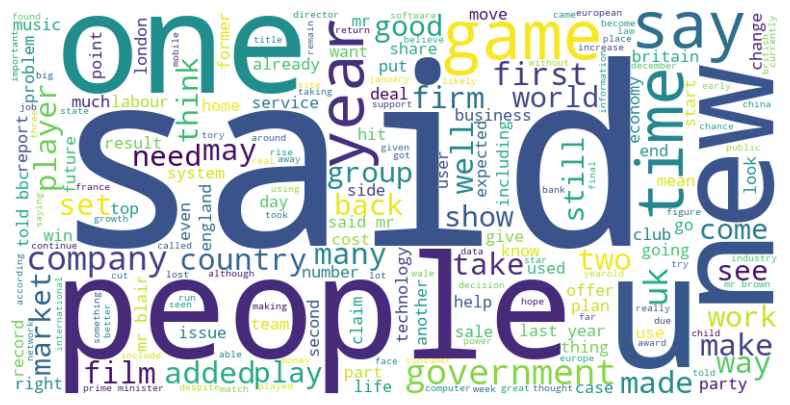

In [78]:
## Plot word cloud lemmatizado
plot_word_cloud(processed_text_lemmatize)

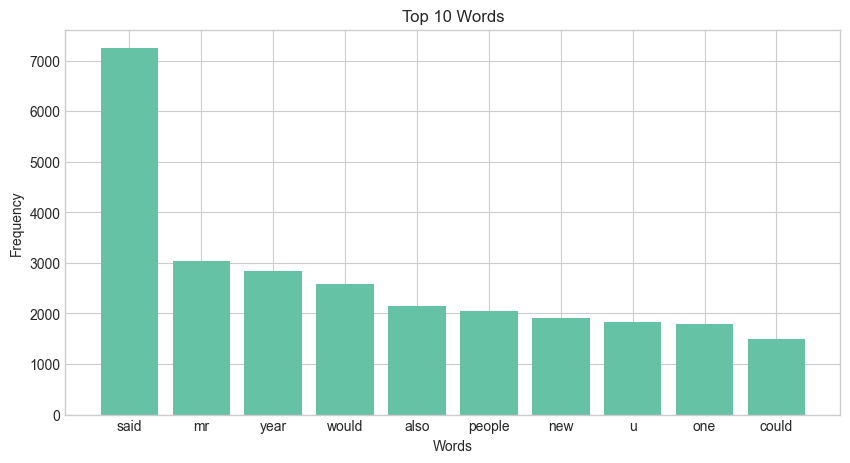

In [79]:
## Plot frequencia lemmatizado
plot_bar_frequencia(processed_text_lemmatize)

### Vetorização

In [80]:
bow_ngram_model = CountVectorizer(ngram_range=(1,1), max_features=5000)
X = {
    'tfidf': vetorizer_tfidf(processed_text_lemmatize),
    'bow': vetorizer_bow(processed_text_lemmatize),
    'bow_ngram': vetorizer_bow_ngrams(processed_text_lemmatize,bow_ngram_model),
    'w2v': vetorizer_word2vec([text.split() for text in processed_text_lemmatize], vector_size=100, window=5, min_count=5)
}

#### Implementação da busca por similaridade

##### TF-IDF / BoW

Query: 'stock market crash'

1. Similaridade: 0.2387 | Categoria: business
   Excerto:  The market, former British government minister Michael Heseltine once said, has no morality.  And indeed, stock exchange traders around Asia have was...

2. Similaridade: 0.1929 | Categoria: business
   Excerto:  Standard Life, Europe's largest mutual life insurer, has cut bonuses for with-profit policyholders.  Annual bonus rates on its with-profits life poli...

3. Similaridade: 0.1682 | Categoria: business
   Excerto:  Life insurer Axa Sun Life has lowered annual bonus payouts for up to 50,000 with-profits investors.  Regular annual bonus rates on former Axa Equity ...

4. Similaridade: 0.1588 | Categoria: business
   Excerto:  Pan-European stock market Euronext has approached the London Stock Exchange (LSE) about a possible takeover bid.  "The approach is at an early stage ...

5. Similaridade: 0.1577 | Categoria: sport
   Excerto:  Greek sprinter Kostas Kenteris has denied claims that he faked 

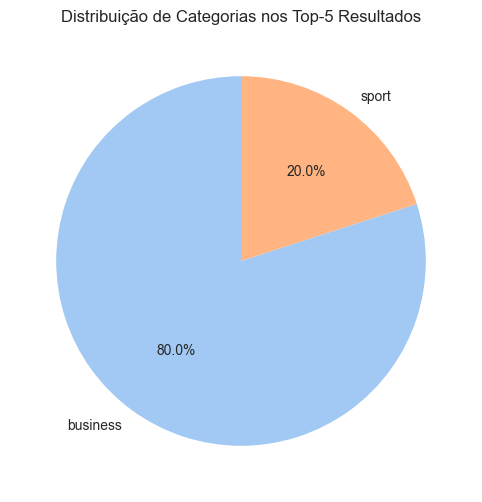

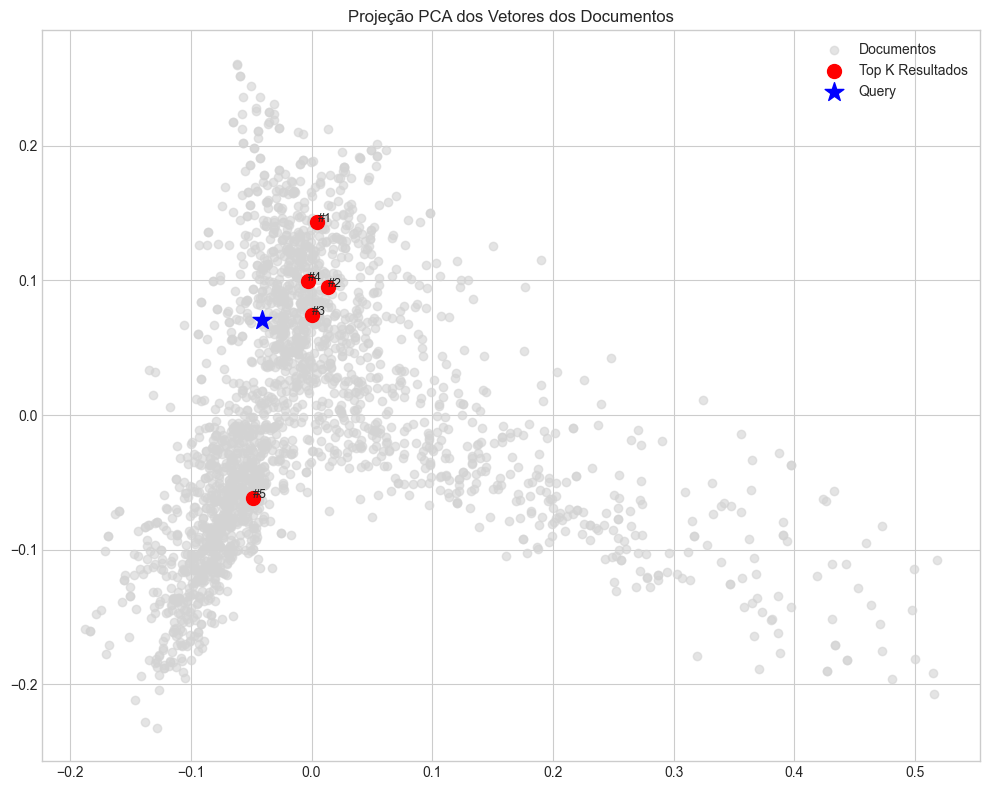

In [81]:
#TF-IDF
tfidf_query_proc,tfidf_q_vec,tfidf_scores,tfidf_indices = buscar("stock market crash", TfidfVectorizer().fit(processed_text_lemmatize), X['tfidf'], y, texts)
plot_category_distribution(y,tfidf_indices)
plot_pca_projection(X['tfidf'].toarray(), tfidf_indices, query_vec=tfidf_q_vec.toarray(), top_k=5)


Query: 'movie award'

1. Similaridade: 0.3832 | Categoria: tech
   Excerto:  PC first person shooter Half-Life 2 has won six Bafta Awards, including best game and best online game.  The title, developed by Valve, was released ...

2. Similaridade: 0.3626 | Categoria: entertainment
   Excerto:  Coronation Street has become the first soap to triumph at the South Bank Show Awards, which traditionally reward highbrow and groundbreaking culture....

3. Similaridade: 0.3231 | Categoria: entertainment
   Excerto:  Michael Moore's anti-Bush documentary Fahrenheit 9/11 has won best film at the US People's Choice Awards, voted for by the US public.  Mel Gibson's T...

4. Similaridade: 0.3218 | Categoria: tech
   Excerto:  The US movie industry has launched legal action to sue people who facilitate illegal film downloading.  The Motion Picture Association of America wan...

5. Similaridade: 0.3175 | Categoria: entertainment
   Excerto:  US actor Jamie Foxx has been given two nominations for Golde

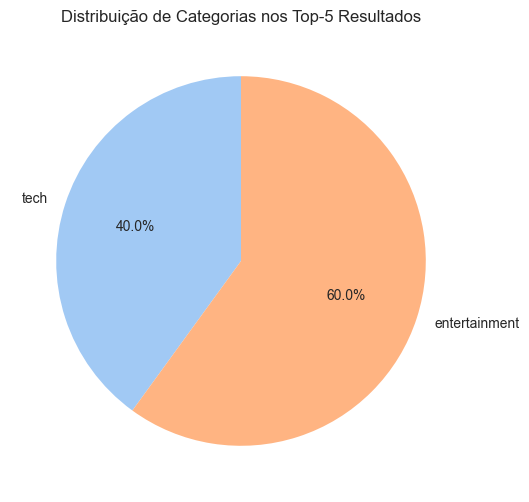

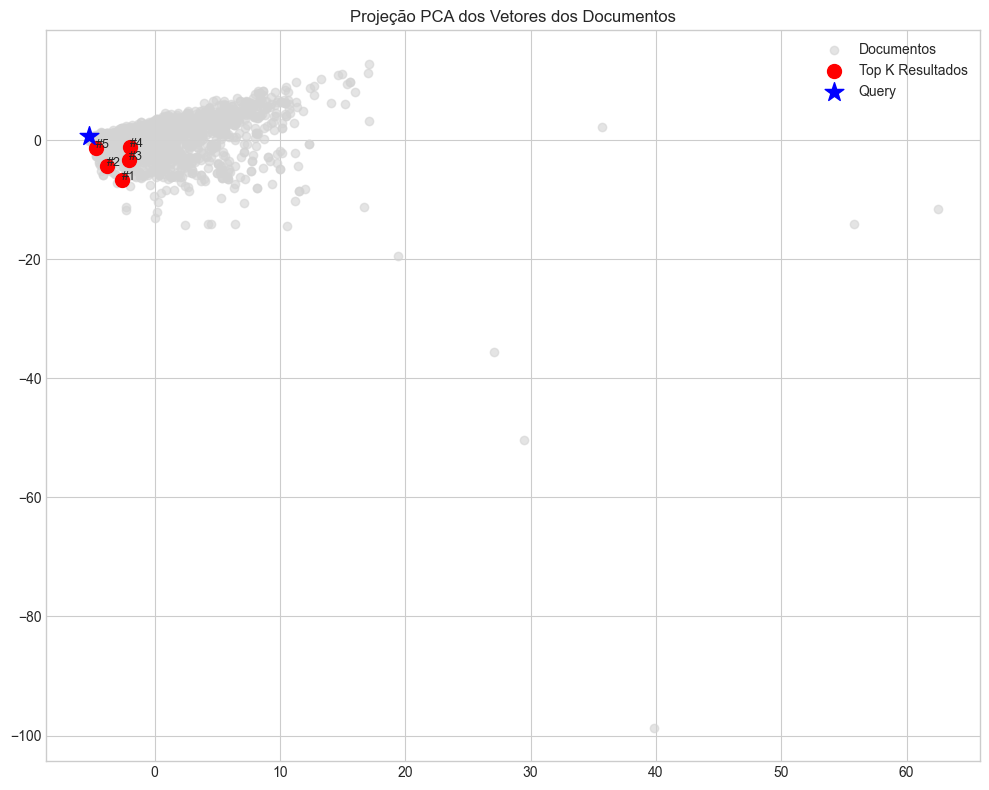

In [82]:
bow_query_proc,bow_q_vec,bow_scores,bow_indices = buscar("movie award", CountVectorizer().fit(processed_text_lemmatize), X['bow'], y, texts)
plot_category_distribution(y,bow_indices)
plot_pca_projection(X['bow'].toarray(), bow_indices, query_vec=bow_q_vec.toarray(), top_k=5)

Query: 'computer'

1. Similaridade: 0.4486 | Categoria: tech
   Excerto:  An executive who froze his broken hard disk thinking it would be fixed has topped a list of the weirdest computer mishaps.  Although computer malfunc...

2. Similaridade: 0.3871 | Categoria: tech
   Excerto:  The once-famous Commodore computer brand could be resurrected after being bought by a US-based digital music distributor.  New owner Yeahronimo Media...

3. Similaridade: 0.3871 | Categoria: tech
   Excerto:  The once-famous Commodore computer brand could be resurrected after being bought by a US-based digital music distributor.  New owner Yeahronimo Media...

4. Similaridade: 0.3475 | Categoria: tech
   Excerto:  Jef Raskin, head of the team behind the first Macintosh computer, has died.  Mr Raskin was one of the first employees at Apple and made many of the d...

5. Similaridade: 0.3430 | Categoria: tech
   Excerto:  The makers of computer programs that secretly spy on what people do with their home PCs co

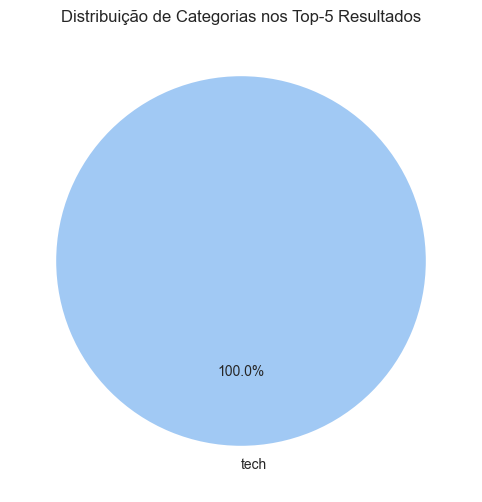

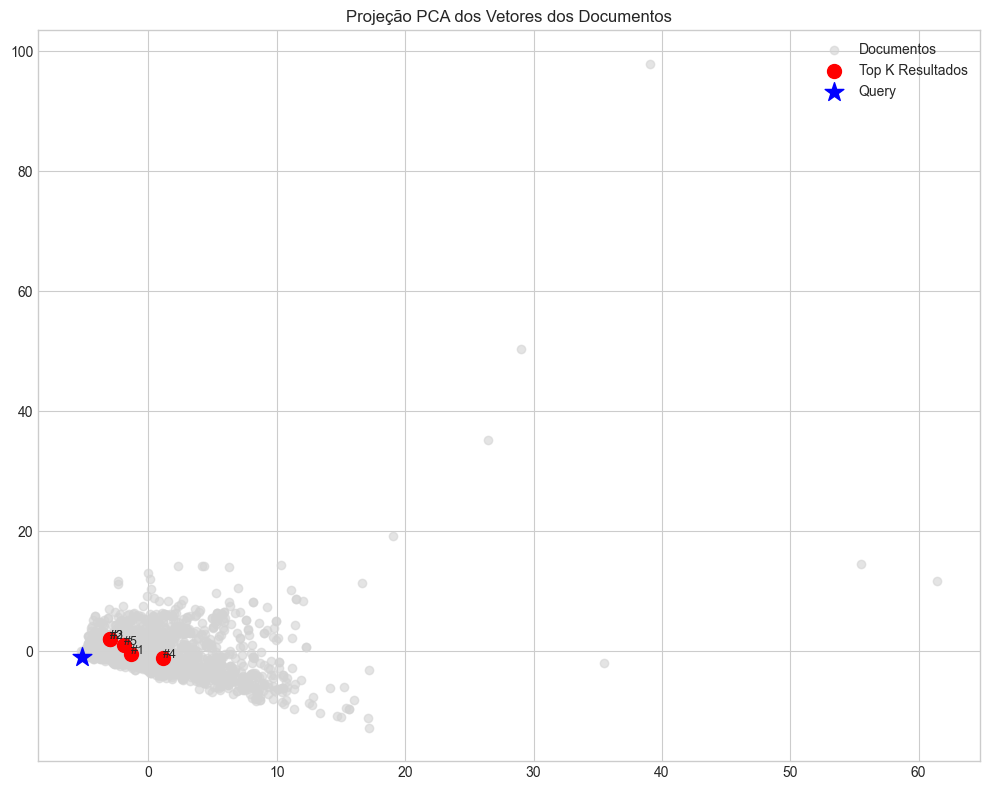

In [83]:
bowngram_query_proc,bowngram_q_vec,bowngram_scores,bowngram_indices = buscar("computer", bow_ngram_model.fit(processed_text_lemmatize), X['bow_ngram'], y, texts)
plot_category_distribution(y,bowngram_indices)
plot_pca_projection(X['bow_ngram'].toarray(), bowngram_indices, query_vec=bowngram_q_vec.toarray(), top_k=5)

##### Word2Vec

In [84]:
tokenized_corpus = [text.split() for text in processed_text_lemmatize]
w2v_model = Word2Vec(tokenized_corpus, vector_size=100, window=5, min_count=5, workers=4)

w2v_query_proc, w2v_q_vec, w2v_scores, w2v_indices = buscar_w2v(
    "computer", 
    w2v_model, 
    X['w2v'], 
    y, 
    texts
)

Query: 'computer'

1. Similaridade: 0.9371 | Categoria: tech
   Excerto:  The fixed line phone in your home could soon be an endangered species.  Research by handset maker Nokia shows that more and more people are using the...

2. Similaridade: 0.9333 | Categoria: tech
   Excerto:  Owners of some Nokia smartphones are being warned to watch out for malicious wallpaper.  Those downloading the software could find all the icons on t...

3. Similaridade: 0.9258 | Categoria: tech
   Excerto:  People using wireless net hotspots will soon be able to make free phone calls as well as surf the net.  Wireless provider Broadreach and net telephon...

4. Similaridade: 0.9258 | Categoria: tech
   Excerto:  People using wireless net hotspots will soon be able to make free phone calls as well as surf the net.  Wireless provider Broadreach and net telephon...

5. Similaridade: 0.9245 | Categoria: tech
   Excerto:  A rapid alerting service that tells home computer users about serious internet security pr

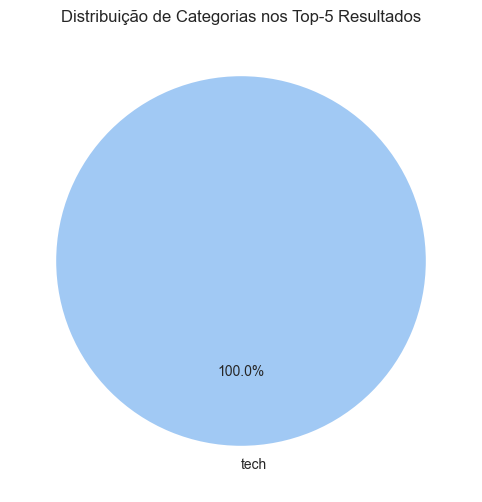

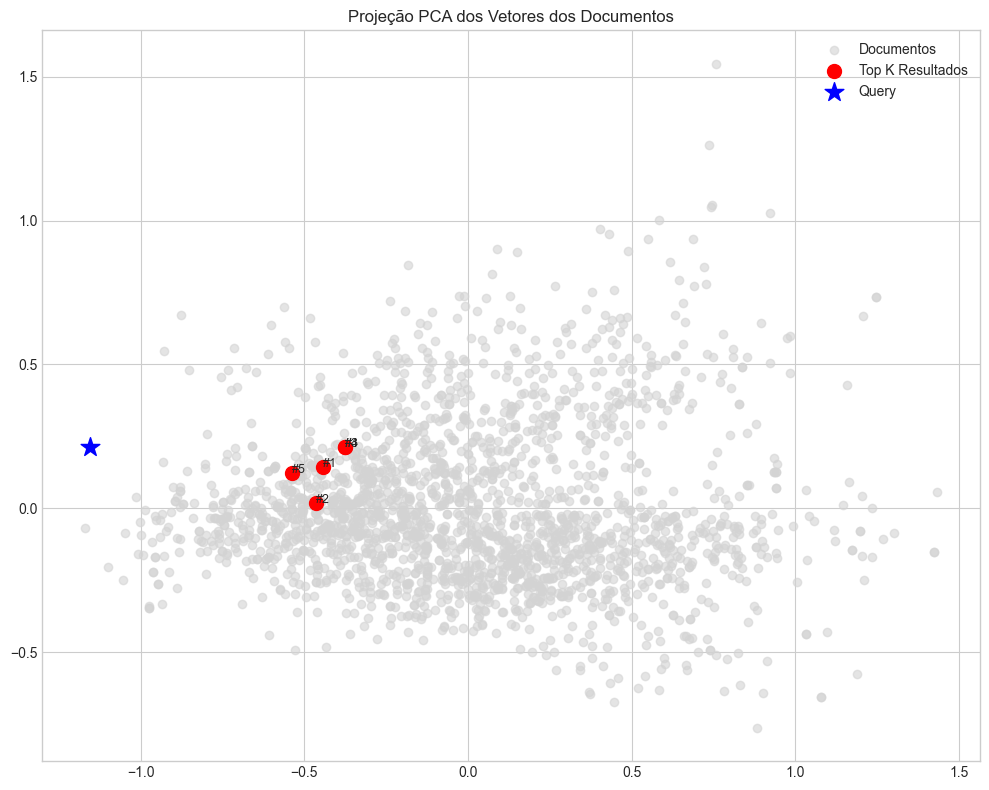

In [85]:
plot_category_distribution(y,w2v_indices)
plot_pca_projection(X['w2v'], w2v_indices, query_vec=w2v_q_vec, top_k=5)

#### Análise EDA textual abrangente

##### Contagem de tokens e top workds

In [86]:
df_clean['token_count'] = df_clean['processed_text'].apply(count_tokens)
# Ver as primeiras linhas
print(df_clean[['category', 'processed_text', 'token_count']].head())


   category                                     processed_text  token_count
0  business  quarterly profit u medium giant timewarner jum...          233
1  business  dollar hit highest level euro almost three mon...          224
2  business  owner embattled russian oil giant yukos ask bu...          150
3  business  british airway blamed high fuel price drop pro...          231
4  business  share uk drink food firm allied domecq risen s...          158


In [87]:
print(get_top_words_clean('tech', df_clean, 5))

[('said', 1567), ('people', 957), ('game', 702), ('technology', 612), ('mobile', 557)]


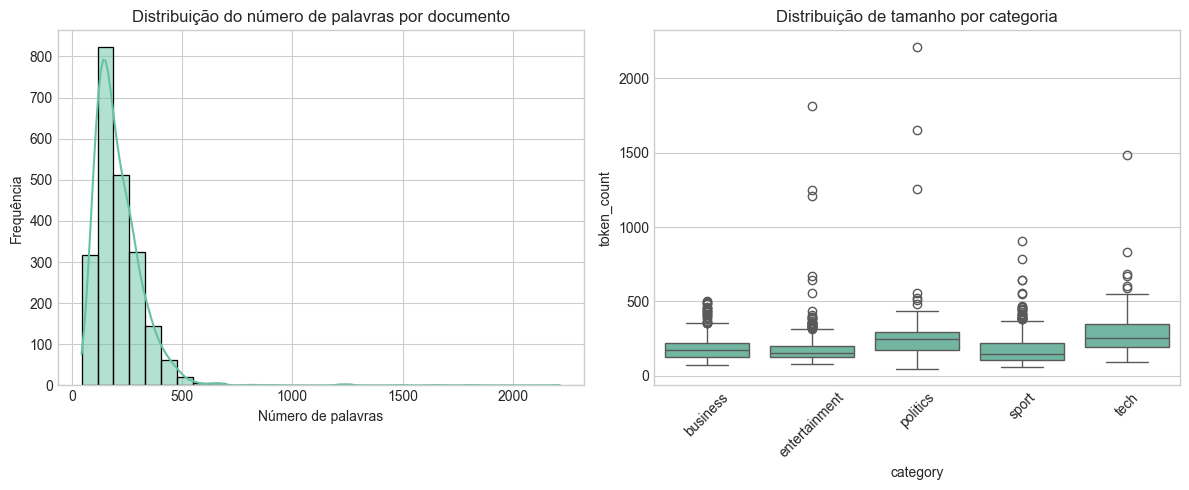

Estatísticas resumidas do comprimento dos documentos por categoria:
               count        mean         std   min    25%    50%     75%  \
category                                                                   
business       510.0  186.635294   77.106949  71.0  130.0  172.0  220.75   
entertainment  386.0  185.632124  137.730659  78.0  127.0  153.0  202.00   
politics       417.0  247.839329  152.657865  44.0  174.0  245.0  292.00   
sport          511.0  177.702544  103.197154  59.0  110.0  149.0  218.00   
tech           401.0  277.603491  125.083592  92.0  195.0  252.0  348.00   

                  max  
category               
business        501.0  
entertainment  1810.0  
politics       2212.0  
sport           906.0  
tech           1482.0  




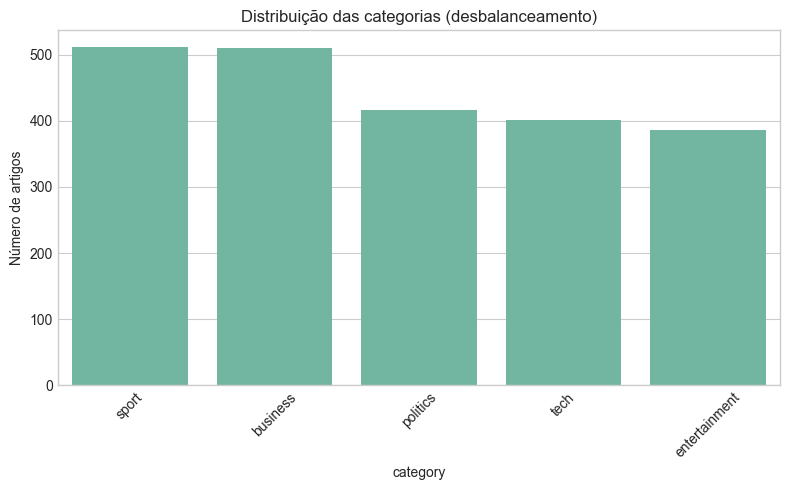

Contagem por categoria:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


Palavras mais frequentes por categoria:

BUSINESS: said, year, bn, u, company, mr, firm, market, would, also
ENTERTAINMENT: film, said, year, best, award, music, also, show, u, one
POLITICS: said, mr, would, government, labour, party, people, election, minister, blair
SPORT: said, game, player, win, year, england, first, would, time, world
TECH: said, people, game, technology, mobile, also, phone, one, mr, service


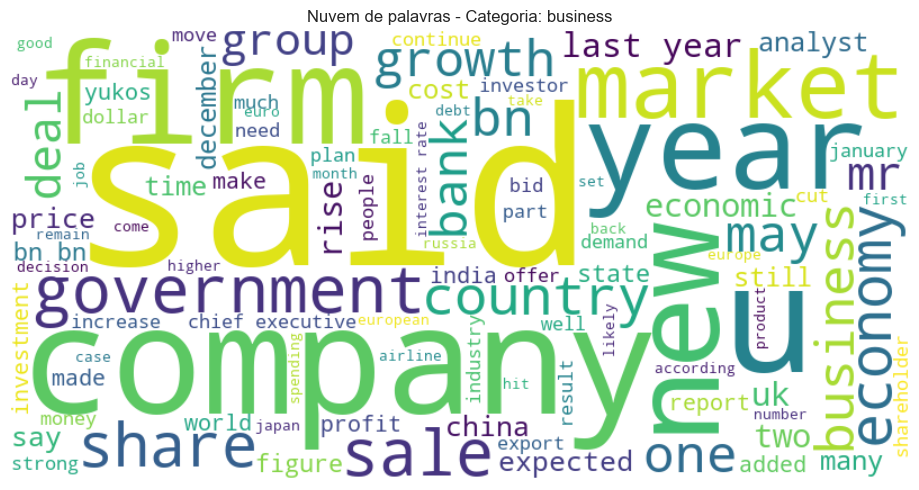

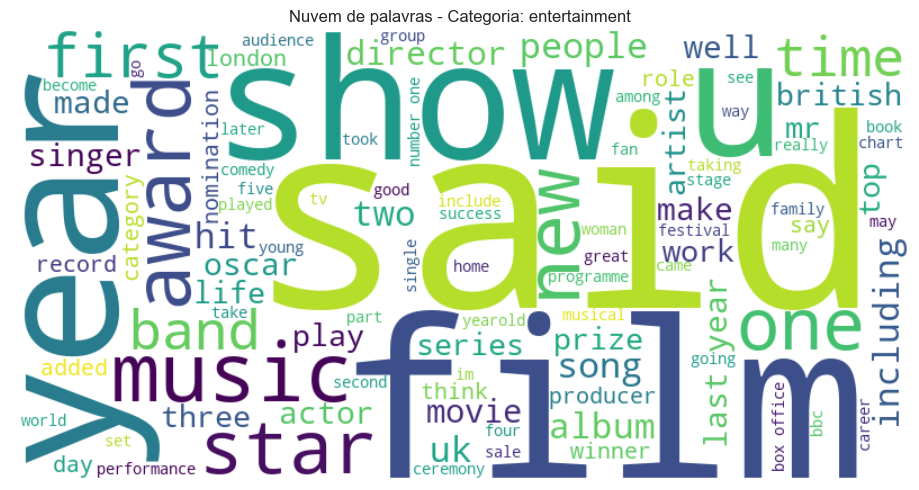

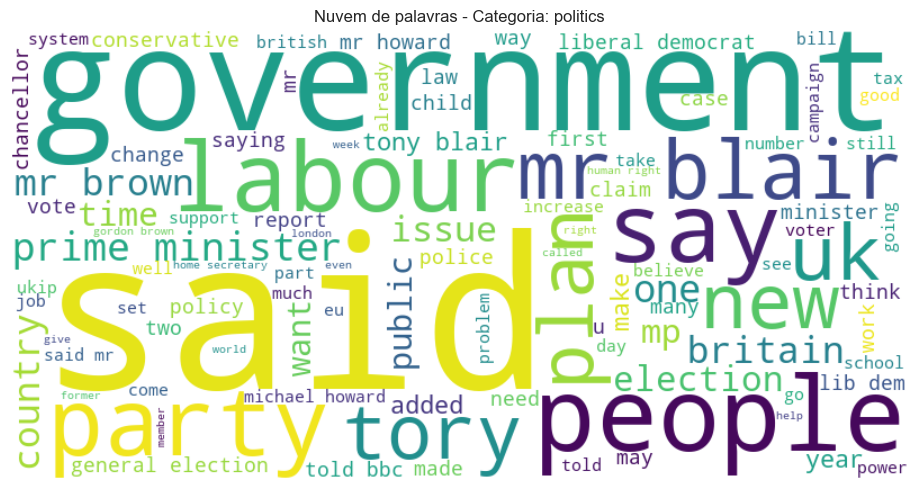

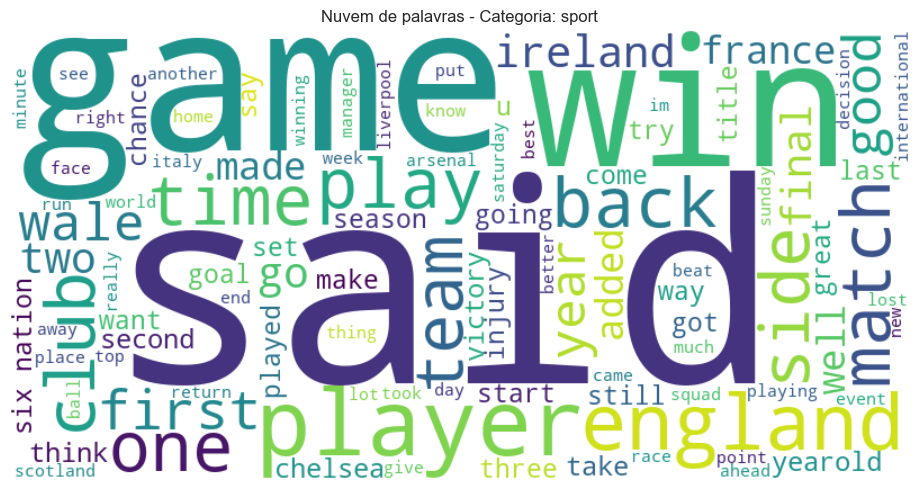

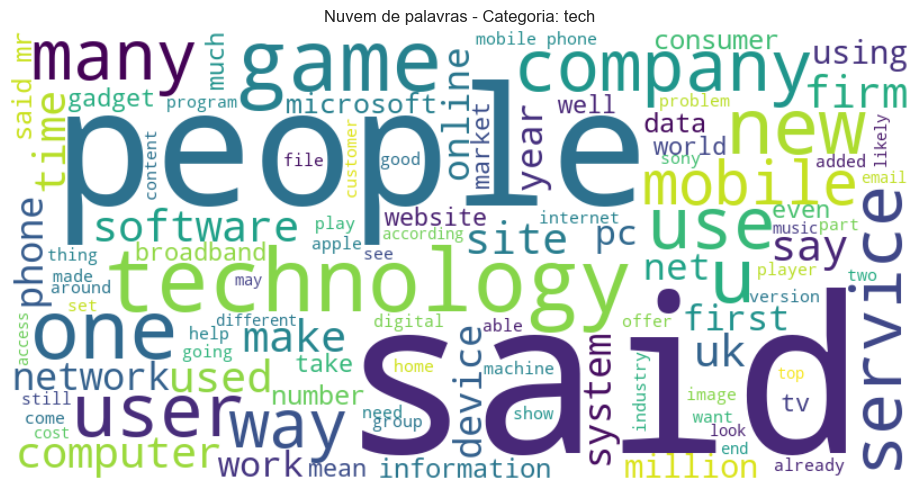

In [88]:
plot_analise_robustes(df_clean)
plot_analise_top_word(df_clean)

Analisando categoria: tech | Documentos: 401
Top 25 palavras consideradas: also, company, computer, could, digital, firm, game, make, many, mobile...
Pares de coocorrência com pelo menos 2 documentos: 300


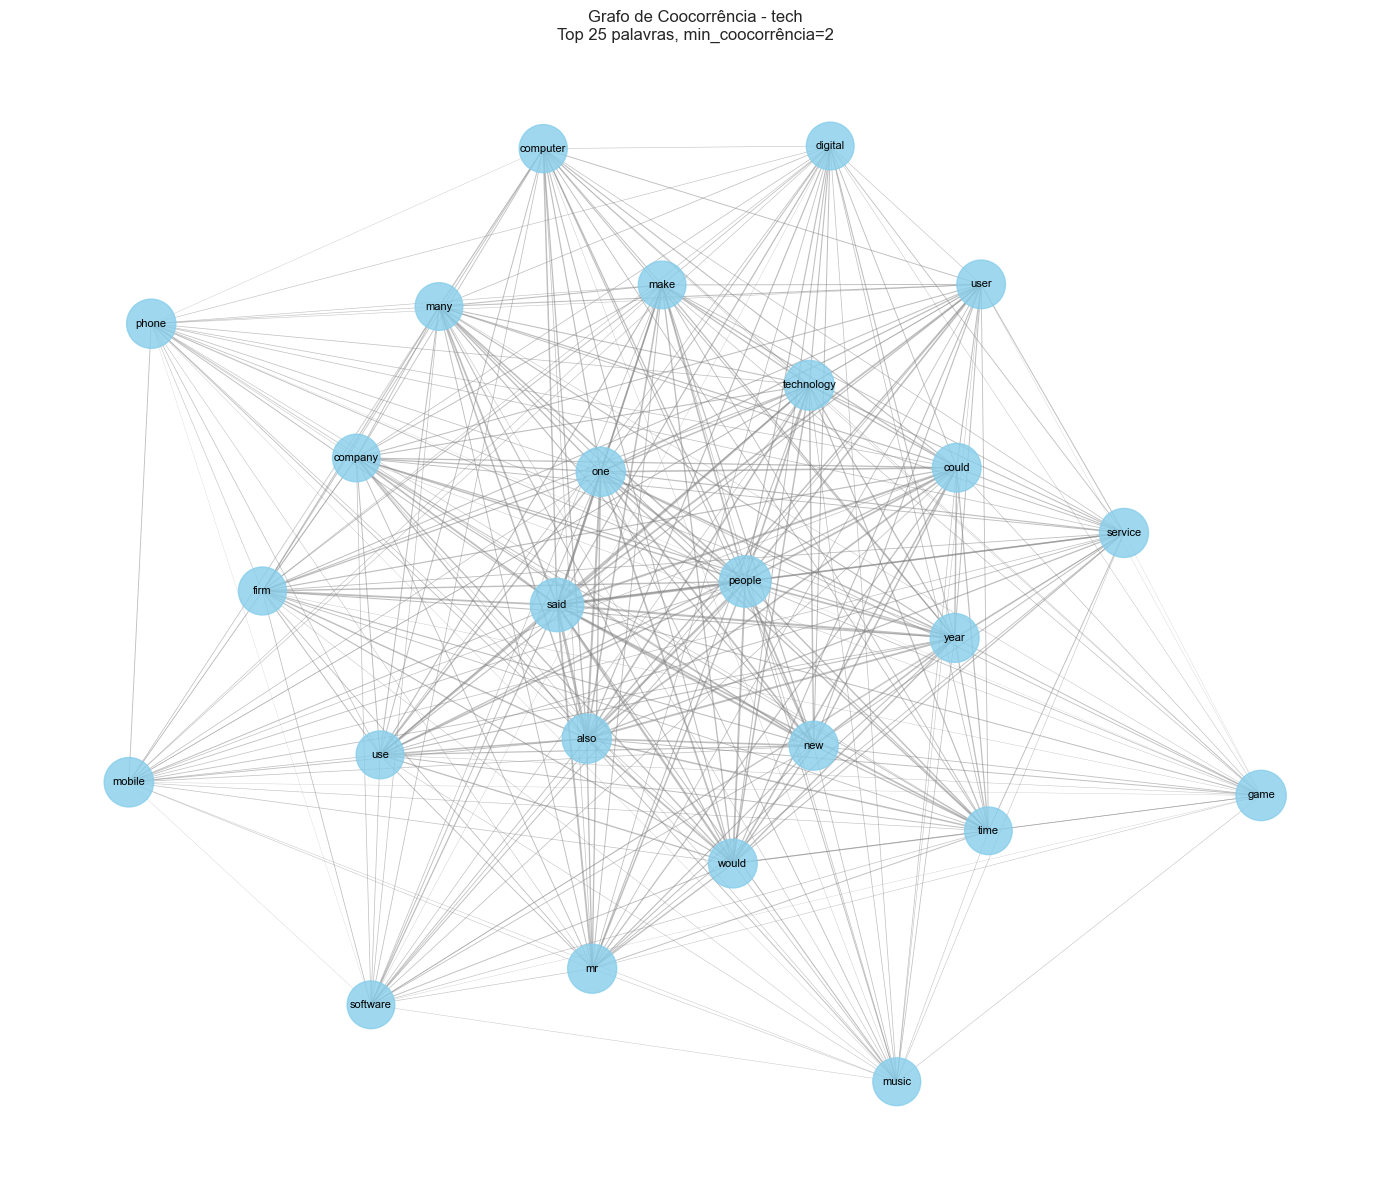


Estatísticas do Grafo:
Nós: 25
Arestas: 300
Densidade: 1.0000
Grau médio: 24.00


In [89]:
G = plot_word_cooccurrence_graph(processed_text_lemmatize, categories=y, 
                                  top_n_words=25, min_cooccurrence=2, 
                                  category_filter='tech', 
                                  figsize=(14, 12), layout='spring', with_labels=True)


### Treinamento

In [90]:
models = [
    ('SVM', SVC(random_state=SEED)),
    ('Logistic Regression', LogisticRegression(random_state=SEED, max_iter=1000)),
    ('Random Forest', RandomForestClassifier(random_state=SEED))
]
y = df['category'].dropna().tolist()
results_by_vectorizer = {}

In [91]:
for vec_name, X_vec in X.items():
    print(f"\n{'='*60}")
    print(f"Vetorização: {vec_name.upper()}")
    print('='*60)
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=SEED, stratify=y
    )
    results = {}
    
    for name, model in models:
        print(f"\n--- Treinando {name} com {vec_name} ---")
        start_time = time.time()
        
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f"Acurácia: {acc:.4f}")
        print(f"Precision (weighted): {prec:.4f}")
        print(f"Recall (weighted): {rec:.4f}")
        print(f"F1-score (weighted): {f1:.4f}")
        print(f"Tempo de treinamento: {training_time:.4f} segundos")
        
        results[name] = {
            'model': model,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'training_time': training_time,
            'classification_report': classification_report(y_test, y_pred, output_dict=True),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }
    
    results_by_vectorizer[vec_name] = results



Vetorização: TFIDF

--- Treinando SVM com tfidf ---
Acurácia: 0.9865
Precision (weighted): 0.9866
Recall (weighted): 0.9865
F1-score (weighted): 0.9865
Tempo de treinamento: 5.6433 segundos

--- Treinando Logistic Regression com tfidf ---
Acurácia: 0.9910
Precision (weighted): 0.9911
Recall (weighted): 0.9910
F1-score (weighted): 0.9910
Tempo de treinamento: 0.5667 segundos

--- Treinando Random Forest com tfidf ---
Acurácia: 0.9753
Precision (weighted): 0.9762
Recall (weighted): 0.9753
F1-score (weighted): 0.9752
Tempo de treinamento: 2.5334 segundos

Vetorização: BOW

--- Treinando SVM com bow ---
Acurácia: 0.9573
Precision (weighted): 0.9596
Recall (weighted): 0.9573
F1-score (weighted): 0.9577
Tempo de treinamento: 3.7021 segundos

--- Treinando Logistic Regression com bow ---
Acurácia: 0.9865
Precision (weighted): 0.9866
Recall (weighted): 0.9865
F1-score (weighted): 0.9864
Tempo de treinamento: 0.6037 segundos

--- Treinando Random Forest com bow ---
Acurácia: 0.9685
Precision (

### Métricas e validações



=== RESUMO COMPARATIVO ENTRE VETORIZAÇÕES ===


Vetorização: TFIDF
  SVM                  | Acc: 0.9865 | F1: 0.9865 | Tempo: 5.64s
  Logistic Regression  | Acc: 0.9910 | F1: 0.9910 | Tempo: 0.57s
  Random Forest        | Acc: 0.9753 | F1: 0.9752 | Tempo: 2.53s

Vetorização: BOW
  SVM                  | Acc: 0.9573 | F1: 0.9577 | Tempo: 3.70s
  Logistic Regression  | Acc: 0.9865 | F1: 0.9864 | Tempo: 0.60s
  Random Forest        | Acc: 0.9685 | F1: 0.9685 | Tempo: 2.63s

Vetorização: BOW_NGRAM
  SVM                  | Acc: 0.9573 | F1: 0.9576 | Tempo: 2.92s
  Logistic Regression  | Acc: 0.9843 | F1: 0.9842 | Tempo: 0.18s
  Random Forest        | Acc: 0.9730 | F1: 0.9730 | Tempo: 1.21s

Vetorização: W2V
  SVM                  | Acc: 0.8202 | F1: 0.8193 | Tempo: 0.14s
  Logistic Regression  | Acc: 0.8225 | F1: 0.8221 | Tempo: 0.10s
  Random Forest        | Acc: 0.8539 | F1: 0.8545 | Tempo: 1.11s


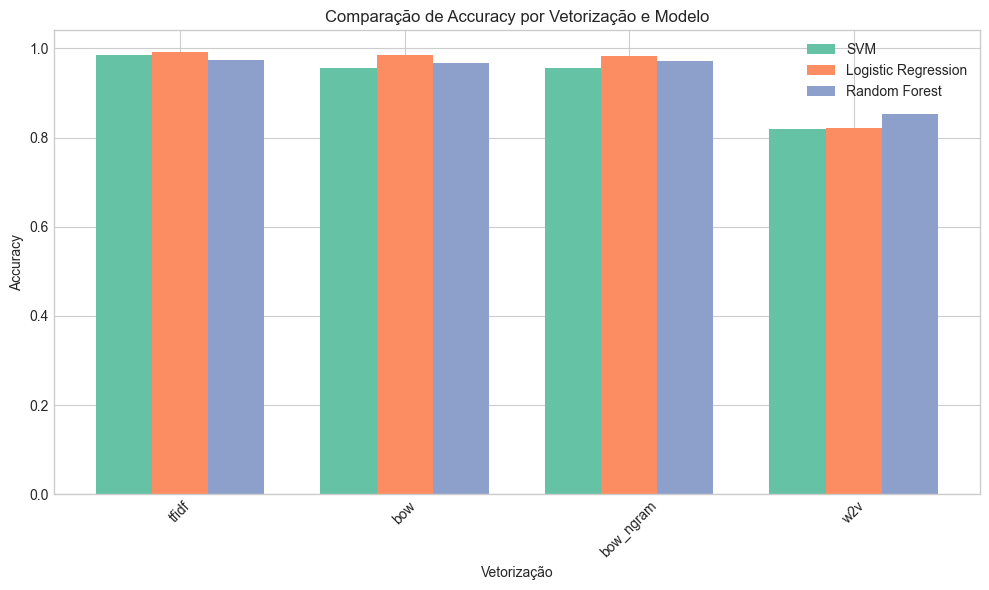

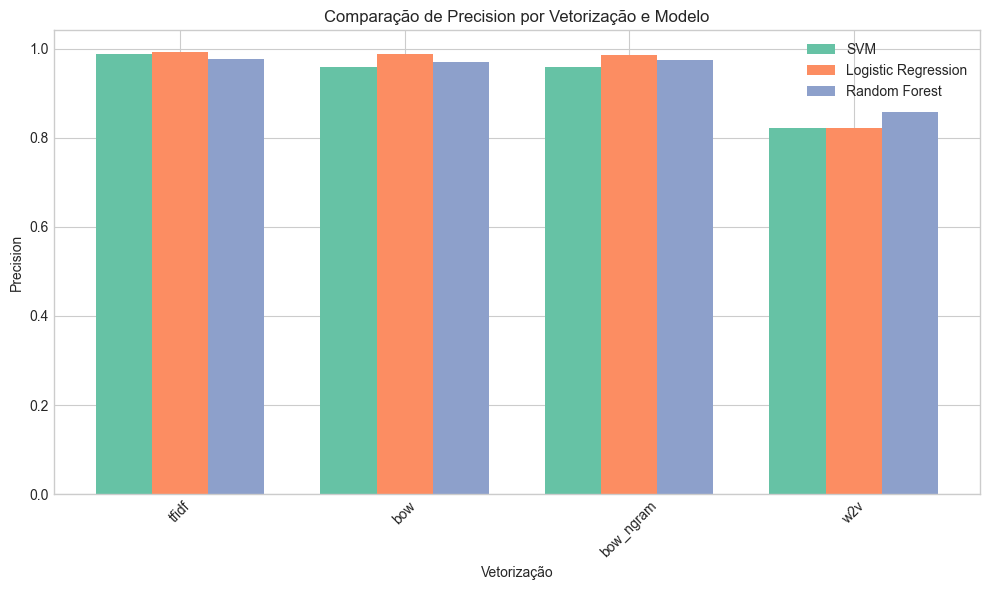

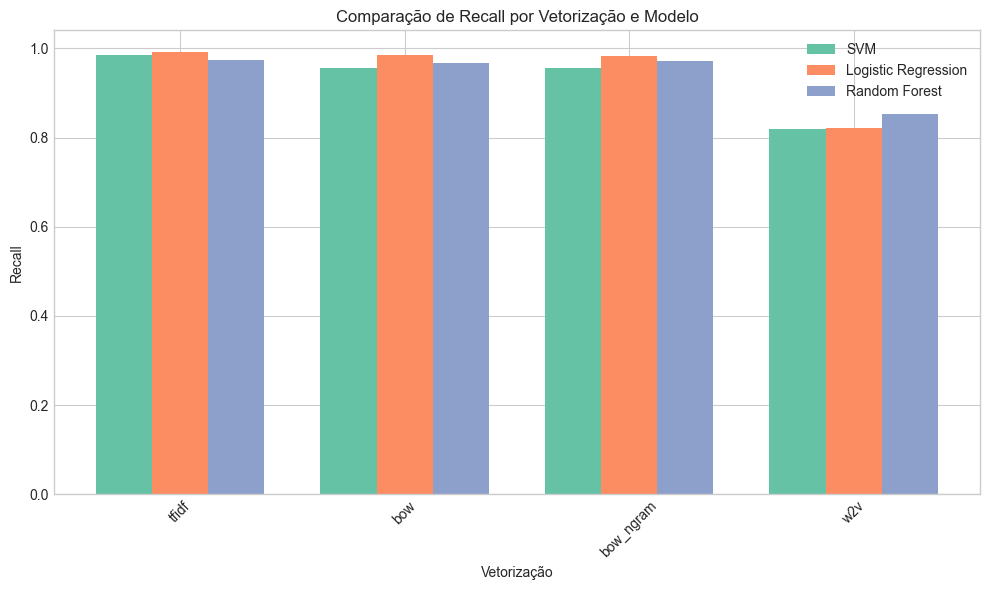

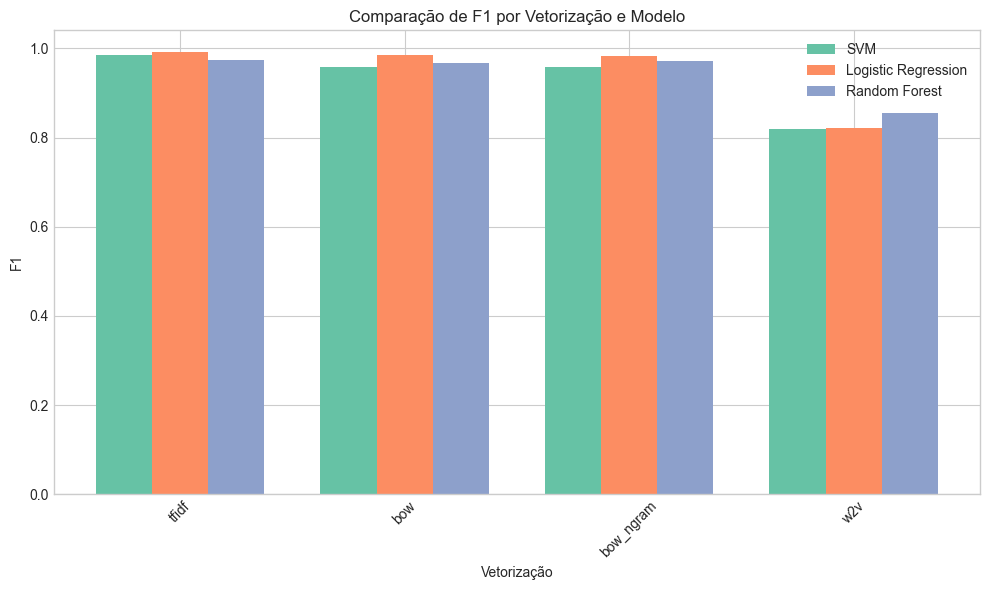

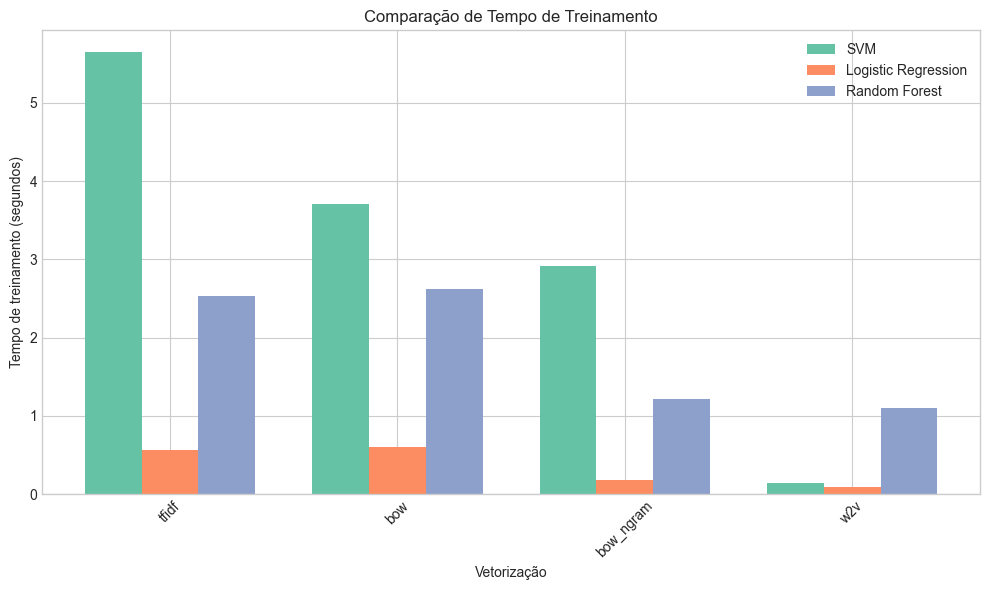

In [ ]:
print("\n\n=== RESUMO COMPARATIVO ===\n")
for vec_name, res in results_by_vectorizer.items():
    print(f"\nVetorização: {vec_name.upper()}")
    for model_name, metrics in res.items():
        print(f"  {model_name:20} | Acc: {metrics['accuracy']:.4f} | F1: {metrics['f1']:.4f} | Tempo: {metrics['training_time']:.2f}s")

vectorizers = list(results_by_vectorizer.keys())
model_names = [m[0] for m in models]
metrics = ['accuracy', 'precision', 'recall', 'f1']

plot_comparison_results(results_by_vectorizer,vectorizers,model_names,metrics)